# Chapter 22 · Amazon SageMaker: walkthrough

Companion to `notes/22_sagemaker.html` (video 10:46:14 – 11:08:48).

In the video: open **SageMaker Studio**, start a **JupyterLab space**, upload a small CSV, write the data to **S3**,
train the built-in **linear-learner** algorithm on a managed instance, `deploy()` it as an **endpoint**, call the endpoint,
then delete everything so it stops costing money.

A real run needs an AWS account and costs money per instance-hour. This notebook runs the same sequence with **moto**,
which pretends to be the AWS APIs on this machine:

| Part | What happens |
|---|---|
| 1 | the data, and a local scikit-learn fit — the thing SageMaker will do on a rented machine |
| 2 | prepare the data the way a built-in algorithm wants it |
| 3 | S3: bucket, `train/` and `test/` prefixes (mocked) |
| 4 | the **training job**: the request `estimator.fit()` builds for you |
| 5 | deploy: `Model` → `EndpointConfig` → `Endpoint` (what `.deploy()` really creates) |
| 6 | call the endpoint and compare with the local model |
| 7 | what it costs, and the cheaper serving options |
| 8 | delete everything, and check it's gone |

**What is faked:** moto stores the API objects and returns statuses; it does not run the algorithm, so the
"predictions" we get back are the ones we seed (computed by the local model). Every request shape is the real one.

In [1]:
import io, json, warnings
from pathlib import Path
import boto3, requests
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from moto import mock_aws
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
HERE = Path.cwd(); REPORTS = HERE / "reports"; REPORTS.mkdir(exist_ok=True)
pd.set_option("display.max_colwidth", 90); pd.set_option("display.width", 200)

REGION   = "ap-south-1"                    # the video works in Mumbai
BUCKET   = "sagemaker-mlops-demo-25"       # S3 names are globally unique
PREFIX   = "linear-learner"                # a folder per algorithm, as in the video
ROLE_ARN = "arn:aws:iam::123456789012:role/service-role/AmazonSageMaker-ExecutionRole-20260101"
# In Studio you never type this: `sagemaker.get_execution_role()` reads the role attached to the space.
print("region:", REGION, "| bucket:", BUCKET)

region: ap-south-1 | bucket: sagemaker-mlops-demo-25


### Where each video step happens

| Video step (Studio / SDK) | The API call underneath | Runs here? |
|---|---|---|
| create a Domain + user profile | `sagemaker:CreateDomain`, `CreateUserProfile` | no (console, one-off) |
| JupyterLab space + "Run space" | `CreateSpace`, `CreateApp` (a rented instance) | no (billed per hour) |
| `sagemaker.Session()`, `get_execution_role()` | STS + config | faked below |
| upload data to S3 | `s3:PutObject` | **yes** (moto) |
| `Estimator(...).fit()` | `sagemaker:CreateTrainingJob` | **yes** (moto) |
| `.deploy()` | `CreateModel` + `CreateEndpointConfig` + `CreateEndpoint` | **yes** (moto) |
| `predictor.predict()` | `sagemaker-runtime:InvokeEndpoint` | **yes** (seeded result) |
| `delete_endpoint()` | `DeleteEndpoint` | **yes** |

## 1 · The data, and a local fit
The video uses a small "study hours → exam score" table from Kaggle (25 rows, two columns) and calls it a regression
problem. Here is an equivalent dataset generated locally, so the notebook needs no download.

In [2]:
rng = np.random.default_rng(7)
hours = np.round(rng.uniform(0.5, 9.5, 25), 1)
scores = np.round(np.clip(9.8 * hours + 2.5 + rng.normal(0, 4.5, 25), 5, 100), 0)
df = pd.DataFrame({"hours": hours, "scores": scores})
print(df.shape)
df.head()

(25, 2)


,hours,scores
0,6.1,61.0
1,8.6,75.0
2,7.5,74.0
3,2.5,27.0
4,3.2,34.0


local scikit-learn fit: score ≈ 9.12 × hours + 4.93
MAE 2.29 | RMSE 3.09


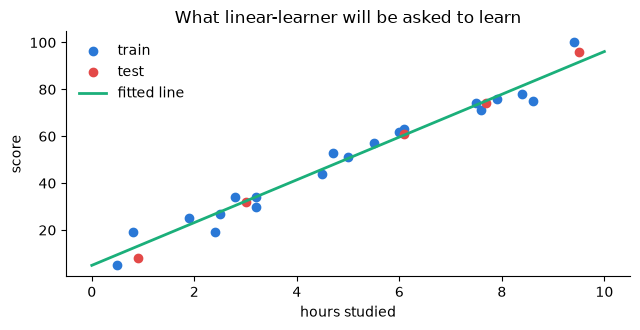

In [3]:
# float32 — the video does this too: type mismatches are a common source of SageMaker errors
X = df[["hours"]].to_numpy(dtype="float32")
y = df["scores"].to_numpy(dtype="float32")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

local = LinearRegression().fit(X_train, y_train)
pred_local = local.predict(X_test)
print(f"local scikit-learn fit: score ≈ {local.coef_[0]:.2f} × hours + {local.intercept_:.2f}")
print(f"MAE {mean_absolute_error(y_test, pred_local):.2f} | RMSE {mean_squared_error(y_test, pred_local) ** 0.5:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.scatter(X_train, y_train, label="train", color="#2a78d6")
ax.scatter(X_test, y_test, label="test", color="#e34948")
xs = np.linspace(0, 10, 50).reshape(-1, 1)
ax.plot(xs, local.predict(xs), color="#1baf7a", linewidth=2, label="fitted line")
ax.set_xlabel("hours studied"); ax.set_ylabel("score"); ax.legend(frameon=False)
ax.set_title("What linear-learner will be asked to learn")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig(REPORTS / "ch22_data.png", dpi=110); plt.show()

25 rows fit in memory a million times over, so this particular model does not need a cluster. The instructor's
argument for SageMaker is the opposite case: *when your laptop can't hold the data or train the model*, you rent a
machine for the minutes you need it. Keep that trade-off in mind — it's the whole value proposition.

## 2 · Prepare the data the way a built-in algorithm wants it
The built-in algorithms read from S3 in one of two formats:

* **CSV** — `ContentType="text/csv"`, **no header**, and the **label in the first column**.
* **RecordIO-protobuf** — a packed binary format (`write_numpy_to_dense_tensor` in the video). It is smaller and
  streams well in Pipe mode, which matters for datasets that are far too big to fit on the instance's disk.

We use CSV here because it's readable; the video uses RecordIO-protobuf because the AWS example it follows does.

In [4]:
def to_csv_bytes(X, y):
    # label first, no header, no index — the format the built-in algorithms expect
    frame = pd.DataFrame({"label": y})
    for i in range(X.shape[1]):
        frame[f"f{i}"] = X[:, i]
    return frame.to_csv(header=False, index=False).encode()

train_bytes, test_bytes = to_csv_bytes(X_train, y_train), to_csv_bytes(X_test, y_test)
print(train_bytes.decode()[:80], "...\n")
print(f"train {len(train_bytes)} bytes, {len(y_train)} rows | test {len(test_bytes)} bytes, {len(y_test)} rows")

53.0,4.7
44.0,4.5
75.0,8.6
62.0,6.0
78.0,8.4
74.0,7.5
34.0,2.8
57.0,5.5
27.0,2.5 ...

train 180 bytes, 20 rows | test 44 bytes, 5 rows


## 3 · S3: the bucket and the prefixes
Everything SageMaker touches goes through S3: input data, the trained model (`model.tar.gz`), and later any captured
requests. The layout mirrors the video: a folder per algorithm, with `train/`, `test/` and `output/` inside it.

In [5]:
mock = mock_aws(); mock.start()          # from here on, every boto3 call is answered locally

s3 = boto3.client("s3", region_name=REGION)
s3.create_bucket(Bucket=BUCKET, CreateBucketConfiguration={"LocationConstraint": REGION})
s3.put_object(Bucket=BUCKET, Key=f"{PREFIX}/train/student_data.csv", Body=train_bytes)
s3.put_object(Bucket=BUCKET, Key=f"{PREFIX}/test/student_data_test.csv", Body=test_bytes)

listing = s3.list_objects_v2(Bucket=BUCKET)["Contents"]
print(f"s3://{BUCKET}/")
for o in listing:
    print(f"   {o['Key']:<45}{o['Size']:>6} bytes")
s3_train = f"s3://{BUCKET}/{PREFIX}/train/"
s3_test  = f"s3://{BUCKET}/{PREFIX}/test/"
output_location = f"s3://{BUCKET}/{PREFIX}/output"
print("\noutput location:", output_location)

s3://sagemaker-mlops-demo-25/


   linear-learner/test/student_data_test.csv        44 bytes
   linear-learner/train/student_data.csv           180 bytes

output location: s3://sagemaker-mlops-demo-25/linear-learner/output


This is the step that failed in the video with **"not authorized"**, and the instructor fixed it by creating a
different bucket. Causes worth knowing, in order of likelihood:

1. the execution **role** has no `s3:PutObject` permission for that bucket (Studio's default role only covers buckets whose name contains `sagemaker`),
2. a **bucket policy** or Block Public Access rule denies it,
3. the bucket is in a **different region** from the session,
4. the name was taken by someone else's account (S3 names are global).

## 4 · The training job
`estimator.fit()` builds one API request. Here it is written out, so you can see exactly what the SDK sends.

In [6]:
# In real code: image_uris.retrieve("linear-learner", REGION) — it returns an AWS-owned ECR image per region.
TRAINING_IMAGE = f"<aws-account-for-{REGION}>.dkr.ecr.{REGION}.amazonaws.com/linear-learner:1"

hyperparameters = {
    "feature_dim": "1",            # number of input columns
    "predictor_type": "regressor", # "binary_classifier" / "multiclass_classifier" for classification
    "mini_batch_size": "4",        # small because the dataset is tiny
    "epochs": "10",
    "num_models": "32",            # linear-learner trains many models in parallel and keeps the best
    "loss": "absolute_loss",       # the video's choice; "squared_loss" is the usual default
}

sm = boto3.client("sagemaker", region_name=REGION)
JOB = "linear-learner-student-scores"
sm.create_training_job(
    TrainingJobName=JOB,
    AlgorithmSpecification={"TrainingImage": TRAINING_IMAGE, "TrainingInputMode": "File"},
    RoleArn=ROLE_ARN,
    HyperParameters=hyperparameters,
    InputDataConfig=[
        {"ChannelName": "train", "ContentType": "text/csv",
         "DataSource": {"S3DataSource": {"S3DataType": "S3Prefix", "S3Uri": s3_train,
                                         "S3DataDistributionType": "FullyReplicated"}}},
        {"ChannelName": "test", "ContentType": "text/csv",
         "DataSource": {"S3DataSource": {"S3DataType": "S3Prefix", "S3Uri": s3_test,
                                         "S3DataDistributionType": "FullyReplicated"}}},
    ],
    OutputDataConfig={"S3OutputPath": output_location},
    ResourceConfig={"InstanceType": "ml.c4.xlarge", "InstanceCount": 1, "VolumeSizeInGB": 5},
    StoppingCondition={"MaxRuntimeInSeconds": 3600},
)
job = sm.describe_training_job(TrainingJobName=JOB)
print("status  :", job["TrainingJobStatus"])
print("instance:", job["ResourceConfig"]["InstanceType"], "×", job["ResourceConfig"]["InstanceCount"])
print("model   :", job["ModelArtifacts"]["S3ModelArtifacts"])

status  : Completed
instance: ml.c4.xlarge × 1
model   : s3://sagemaker-mlops-demo-25/linear-learner/output/linear-learner-student-scores/output/model.tar.gz


Points worth remembering:

* The **algorithm is a container**. A built-in algorithm is an AWS-owned image; your own training script would use a
  framework image (`sagemaker.sklearn.estimator.SKLearn`, PyTorch, XGBoost…) or your own image from ECR. The same
  `CreateTrainingJob` call runs all of them.
* The instance lives **only for the job** and is billed per second while it runs. That's the difference from Chapter 21's
  cluster, which is billed whether or not anything is running.
* The result is a `model.tar.gz` in S3. Nothing is "deployed" yet.
* Training input can be `File` (copy everything to the instance first) or `Pipe`/`FastFile` (stream from S3).

## 5 · Deploy: three objects, one line of SDK
`predictor = estimator.deploy(initial_instance_count=1, instance_type="ml.m4.xlarge")` creates **three** things.

In [7]:
MODEL, CONFIG, ENDPOINT = "linear-learner-model", "linear-learner-config", "linear-learner-endpoint"

sm.create_model(                                   # 1. what to run: image + weights + role
    ModelName=MODEL,
    PrimaryContainer={"Image": TRAINING_IMAGE,
                      "ModelDataUrl": job["ModelArtifacts"]["S3ModelArtifacts"]},
    ExecutionRoleArn=ROLE_ARN)

sm.create_endpoint_config(                         # 2. how to run it: instance type, count, traffic split
    EndpointConfigName=CONFIG,
    ProductionVariants=[{"VariantName": "AllTraffic", "ModelName": MODEL,
                         "InitialInstanceCount": 1, "InstanceType": "ml.m4.xlarge",
                         "InitialVariantWeight": 1.0}])

sm.create_endpoint(EndpointName=ENDPOINT, EndpointConfigName=CONFIG)   # 3. the HTTPS endpoint itself
ep = sm.describe_endpoint(EndpointName=ENDPOINT)
print("endpoint:", ep["EndpointName"], "→", ep["EndpointStatus"])
print("variant :", ep["ProductionVariants"][0]["VariantName"] if ep.get("ProductionVariants") else "AllTraffic")
print("\nIn the console: SageMaker AI → Inference → Endpoints (the screen the video opens).")

endpoint: linear-learner-endpoint → InService
variant : AllTraffic

In the console: SageMaker AI → Inference → Endpoints (the screen the video opens).


Why three objects instead of one? Because each can change on its own:

* several **variants** in one config give you A/B tests or canaries (weights decide the traffic split),
* a new config can be applied with `UpdateEndpoint`, which swaps instances **without downtime**,
* the same model can sit behind several endpoints (real-time, serverless, asynchronous).

## 6 · Call the endpoint

In [8]:
# moto doesn't run the algorithm, so we seed the response. The numbers are our local model's predictions —
# a real linear-learner, trained on the same data, would return something very close.
seeded = {"predictions": [{"score": round(float(p), 3)} for p in pred_local]}
requests.post("http://motoapi.amazonaws.com/moto-api/static/sagemaker/endpoint-results",
              json={"region": REGION,
                    "results": [{"Body": json.dumps(seeded), "ContentType": "application/json",
                                 "InvokedProductionVariant": "AllTraffic", "CustomAttributes": ""}]})

runtime = boto3.client("sagemaker-runtime", region_name=REGION)
payload = "\n".join(f"{x[0]:.1f}" for x in X_test).encode()   # CSV, no label column at inference time
response = runtime.invoke_endpoint(EndpointName=ENDPOINT, ContentType="text/csv", Body=payload)
body = json.loads(response["Body"].read())
print("request body :", payload.decode().replace("\n", " | "))
print("variant      :", response["InvokedProductionVariant"])
print("response     :", json.dumps(body)[:120], "…\n")

out = pd.DataFrame({"hours": X_test.ravel(), "actual": y_test,
                    "endpoint": [p["score"] for p in body["predictions"]],
                    "local model": pred_local.round(3)})
out

request body : 7.7 | 9.5 | 6.1 | 0.9 | 3.0
variant      : AllTraffic
response     : {"predictions": [{"score": 75.159}, {"score": 91.575}, {"score": 60.566}, {"score": 13.141}, {"score": 32.293}]} …



,hours,actual,endpoint,local model
0,7.7,74.0,75.159,75.158997
1,9.5,96.0,91.575,91.574997
2,6.1,61.0,60.566,60.566002
3,0.9,8.0,13.141,13.141000
4,3.0,32.0,32.293,32.292999


That JSON shape — `{"predictions": [{"score": …}]}` — is what the built-in regressors really return, which is why the
video pulls the numbers out of the response rather than using them directly. For other content types you set a
**serializer** and **deserializer** on the predictor (the video adds them after hitting an error).

## 7 · What it costs
This is the part the instructor repeats: *"SageMaker is a little bit costly — take care about the cost"*, and
*"make sure you delete the endpoint, otherwise it will charge you"*.

The trap is the difference between the two resources:

In [9]:
PRICE = 0.25          # ILLUSTRATIVE $/hour for a small ml.* instance — look up the real number for your region
rows = [
    ("Studio JupyterLab space", "while the space is running", 3, 3 * PRICE),
    ("Training job (ml.c4.xlarge)", "per second, only while training", 0.1, 0.1 * PRICE),
    ("Real-time endpoint (ml.m4.xlarge)", "every hour it exists, even with 0 requests", 730, 730 * PRICE),
]
pd.DataFrame(rows, columns=["resource", "billed", "hours in a month (example)", f"cost at ${PRICE}/h"]).round(2)

,resource,billed,hours in a month (example),cost at $0.25/h
0,Studio JupyterLab space,while the space is running,3.0,0.75
1,Training job (ml.c4.xlarge),"per second, only while training",0.1,0.02
2,Real-time endpoint (ml.m4.xlarge),"every hour it exists, even with 0 requests",730.0,182.50


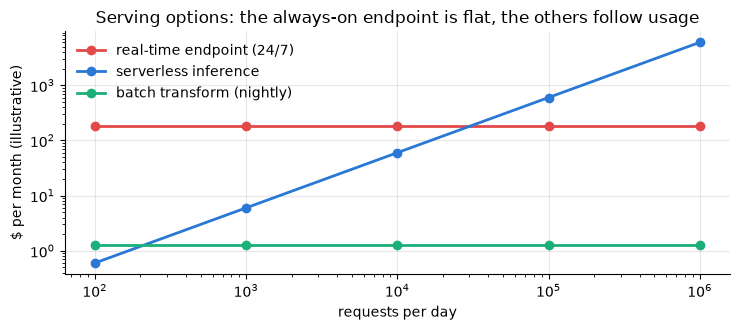

Shape of the argument, not a quote: check the SageMaker pricing page for real numbers.


In [10]:
# a month of serving: always-on endpoint vs serverless vs a nightly batch job
req_per_day = np.array([100, 1_000, 10_000, 100_000, 1_000_000])
endpoint = np.full_like(req_per_day, 730 * PRICE, dtype=float)              # flat: you rent the instance
serverless = req_per_day * 30 * 0.0000002 * 1000                            # illustrative per-request pricing
batch = np.full_like(req_per_day, 30 * (10 / 60) * PRICE, dtype=float)      # 10 min of an instance per night

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(req_per_day, endpoint, marker="o", label="real-time endpoint (24/7)", color="#e34948", linewidth=2)
ax.plot(req_per_day, serverless, marker="o", label="serverless inference", color="#2a78d6", linewidth=2)
ax.plot(req_per_day, batch, marker="o", label="batch transform (nightly)", color="#1baf7a", linewidth=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("requests per day"); ax.set_ylabel("$ per month (illustrative)")
ax.set_title("Serving options: the always-on endpoint is flat, the others follow usage")
ax.legend(frameon=False); ax.grid(alpha=.3)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig(REPORTS / "ch22_cost.png", dpi=110); plt.show()
print("Shape of the argument, not a quote: check the SageMaker pricing page for real numbers.")

Reading the chart: a **real-time endpoint** costs the same whether it serves 100 requests a day or a million, because
you are renting an instance by the hour. **Serverless inference** charges per request (with cold starts as the
trade-off), and **batch transform** starts an instance, scores a file and shuts down.

Rules of thumb:
* prototype / low traffic → **serverless inference**
* steady traffic, tight latency → **real-time endpoint** (with autoscaling, min instances ≥ 1)
* scheduled scoring of a whole table → **batch transform**, no endpoint at all
* long-running requests (big documents, video) → **asynchronous inference**

## 8 · Delete everything
The order matters: endpoint → endpoint config → model. Then the bucket and the Studio space.

In [11]:
sm.delete_endpoint(EndpointName=ENDPOINT)          # stops the hourly charge  (predictor.delete_endpoint())
sm.delete_endpoint_config(EndpointConfigName=CONFIG)
sm.delete_model(ModelName=MODEL)
try:
    sm.describe_endpoint(EndpointName=ENDPOINT)
except Exception as e:
    print("describe_endpoint after delete →", e.response["Error"]["Code"], "(the endpoint is gone; billing stops)")

objs = s3.list_objects_v2(Bucket=BUCKET).get("Contents", [])
s3.delete_objects(Bucket=BUCKET, Delete={"Objects": [{"Key": o["Key"]} for o in objs]})   # a bucket must be empty first
s3.delete_bucket(Bucket=BUCKET)
print("buckets left:", [b["Name"] for b in s3.list_buckets()["Buckets"]] or "none")
mock.stop()

describe_endpoint after delete → ValidationException (the endpoint is gone; billing stops)
buckets left: none


In [12]:
checklist = pd.DataFrame([
    ("Endpoint", "predictor.delete_endpoint() / console → Inference → Endpoints", "the big one: billed per hour, forever"),
    ("Endpoint config + Model", "delete_endpoint_config / delete_model", "free, but they clutter the account"),
    ("JupyterLab space", "Studio → space → Stop, then Delete", "billed while running; stopping is enough to stop the charge"),
    ("Studio domain", "delete only if you're done with SageMaker entirely", "the domain itself is free; its EFS storage is not"),
    ("S3 data + model.tar.gz", "empty the bucket, then delete it", "per GB-month"),
    ("Training jobs", "nothing to delete", "already stopped; they only cost while running"),
], columns=["resource", "how", "note"])
checklist

,resource,how,note
0,Endpoint,predictor.delete_endpoint() / console → Inference → Endpoints,"the big one: billed per hour, forever"
1,Endpoint config + Model,delete_endpoint_config / delete_model,"free, but they clutter the account"
2,JupyterLab space,"Studio → space → Stop, then Delete",billed while running; stopping is enough to stop the charge
3,Studio domain,delete only if you're done with SageMaker entirely,the domain itself is free; its EFS storage is not
4,S3 data + model.tar.gz,"empty the bucket, then delete it",per GB-month
5,Training jobs,nothing to delete,already stopped; they only cost while running


**Next:** the after-course to-do list has the real version of this notebook — a Studio domain on your own account,
one training job and one endpoint on the smallest instance, then delete it the same day.